# A model that fit Bitcoin at 95% — and knew nothing 📐
### Stock-to-Flow — the most famous Bitcoin valuation model, and the most famously busted

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Holds_out--of--sample%3F: Busted](https://img.shields.io/badge/Holds_out--of--sample%3F-Busted-8b949e?style=flat-square)

In 2019 an anonymous analyst called **PlanB** published a chart that went viral. He measured Bitcoin's *scarcity* — the ratio of coins that already exist to the trickle of new ones mined each year ("stock-to-flow") — and showed it lined up almost perfectly with Bitcoin's price. The fit was a jaw-dropping **95%**. The model predicted a six-figure Bitcoin, and for a while it looked like prophecy.

Then 2022 happened. Bitcoin crashed to $17,000 while the model insisted it should be worth *six figures*. The prophecy became a punchline. This notebook asks the question everyone skipped in 2019: **was there ever anything there?**

> 📓 **Plain-language layer.** Want the spurious-regression proof and the HAC *t*-stats? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** The one honest test of any predictive model is to freeze it at the moment it was published and see what it did *next*. That's what we do here. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stock_to_flow import data, strategy as st

SF = data.supply_flow_daily()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    BTC = data.load_btc()
    DF = data.join_price_sf(BTC)
    OOS = st.oos_fit_stats(DF, data.PUBLICATION_DATE)
    A, B = OOS["a"], OOS["b"]
    MODEL = st.model_price(DF, A, B)
    RESID = st.valuation_residual(DF, A, B)
else:
    BTC = DF = OOS = A = B = MODEL = RESID = None
print("real cache present:", HAVE_REAL, "| S2F curve points:", len(SF),
      "| SF today:", round(float(SF['sf'].iloc[-1] if not HAVE_REAL else DF['sf'].iloc[-1]), 1))

# frozen headline numbers (mirror of docs/results.md)
R = {'btc_lo': '2014-09-17', 'btc_hi': '2026-06-30', 'btc_n': 4305, 'fp': '74d40e852645', 'sf_now': 122, 'supply_now_m': 20.05, 'pub': '2019-03-22', 'steel_r2': 0.8866, 'steel_b': 2.458, 'steel_n': 142, 'r2_sf': 0.8803, 'r2_time': 0.8758, 'corr_sf_time': 0.9643, 'a': -0.8711, 'b': 2.7661, 'n_train': 1648, 'n_oos': 2657, 'r2_in': 0.705, 'r2_oos': 0.2132, 'rmse_in': 0.739, 'rmse_oos': 0.7702, 'pred': {'2021-11-30': (57005, 30857, 1.85), '2022-11-30': (17169, 32384, 0.53), '2024-12-31': (93429, 239071, 0.39), '2026-06-30': (58559, 247369, 0.24)}, 'fwd': {30: (-0.015, -0.62, -1.48), 90: (-0.121, -1.51, -2.5), 180: (-0.435, -1.68, -2.81), 365: (-0.187, -0.45, -1.64)}, 'oos_expo': 59, 'oos_switches': 9, 'oos_years': 7.3, 'oos_net': 328, 'oos_gross': 332, 'oos_net_sharpe': 0.71, 'oos_bh': 1355, 'oos_bh_sharpe': 0.91, 'oos_plac_mean': 87, 'oos_plac_p95': 409, 'p21_expo': 78, 'p21_years': 4.7, 'p21_net': 7, 'p21_bh': -4, 'p21_net_sharpe': 0.25, 'p21_bh_sharpe': 0.24, 'p21_plac_mean': -39, 'p21_plac_p95': 17, 'syn_null_mean': 0.17, 'syn_null_sd': 1.29, 'syn_null_fire': 5, 'syn_planted': -5.96}


real cache present: True | S2F curve points: 6938 | SF today: 122.1


## The answer first

| Question | Answer |
|---|---|
| Did the model really fit at ~95%? | **Yes — and that's the trap.** On the full history it fits at R² ≈ **0.89**. But Bitcoin's stock-to-flow is basically a *calendar* (it's set by a fixed schedule), and it's **96%** correlated with time itself. Fit price against a plain clock and you get R² = **0.88** — the same thing. |
| What happened after it was published? | Freeze the model in March 2019 and let it run: its fit **collapses** from 70% to **21%**. By 2026 it predicts BTC at **$247,369** — the real price is **$58,559**, four times lower. |
| Could you have traded it? | "Buy when Bitcoin is cheap vs the model" returned **+328%** — while just **holding** returned **+1,355%**. The strategy lost to doing nothing, and did no better than buying on **random** days. |
| So was there ever a signal? | **No.** A beautiful curve fit to a clock. It described the past and predicted nothing. |

> Fitting a rising line to another rising line is the oldest illusion in statistics. The 95% was real. The prophecy was not.

## 1 · The claim

> *"Bitcoin is priced by its scarcity. Take the stock of existing coins, divide by the annual flow of new ones — that's the stock-to-flow ratio, and it doubles at every 'halving.' Plot Bitcoin's market value against it and you get a straight line on a log-log chart with 95% R². Since the future supply schedule is known years in advance, the model tells you what Bitcoin will be worth: six figures after the 2020 halving, ~$288,000 after 2024."*

It's a genuinely seductive idea: a valuation you can compute from Bitcoin's own **deterministic issuance rules**, no market data required. Gold has a high stock-to-flow; so does silver; Bitcoin's climbs toward gold's with every halving. If scarcity really set the price, this would be one of the few honest crystal balls in finance.

## 2 · So what?

If S2F were real it would be extraordinary — a risk asset whose fair value you could read years ahead off a schedule carved into the protocol. It became the reference model of the 2020–2021 bull market: quoted in research notes, printed on dashboards, used to justify "$100k is conservative." The stakes are simple. If the model works, scarcity is destiny and you buy every dip below the line. If it doesn't, it's a textbook lesson in how a spectacular-looking fit can be *manufactured* by two numbers that both happen to go up over time — and a cautionary tale about every model sold on its R².

## 3 · How would we even know?

- **Rebuild the model honestly.** Reconstruct stock-to-flow straight from Bitcoin's halving schedule (this part is exact — issuance is consensus law), fit PlanB's log-log line, and reproduce the famous ~95%.
- **Is the fit a clock?** Race the stock-to-flow fit against fitting price to *plain calendar time*. If a clock does just as well, the "scarcity" story adds nothing.
- **Freeze it at publication.** Fit the model using *only* data available in March 2019, then see how its predictions held up over the next seven years — the crash, the recoveries, today.
- **Try to trade it.** Buy Bitcoin whenever it's below the model line ("cheap"), sit in cash otherwise. Beat buy-and-hold? Beat *random* buy dates?

## 4 · The teardown — let's actually look

**First, the famous chart.** Here is Bitcoin's price against the model line built from stock-to-flow. It really does look like a law of nature.

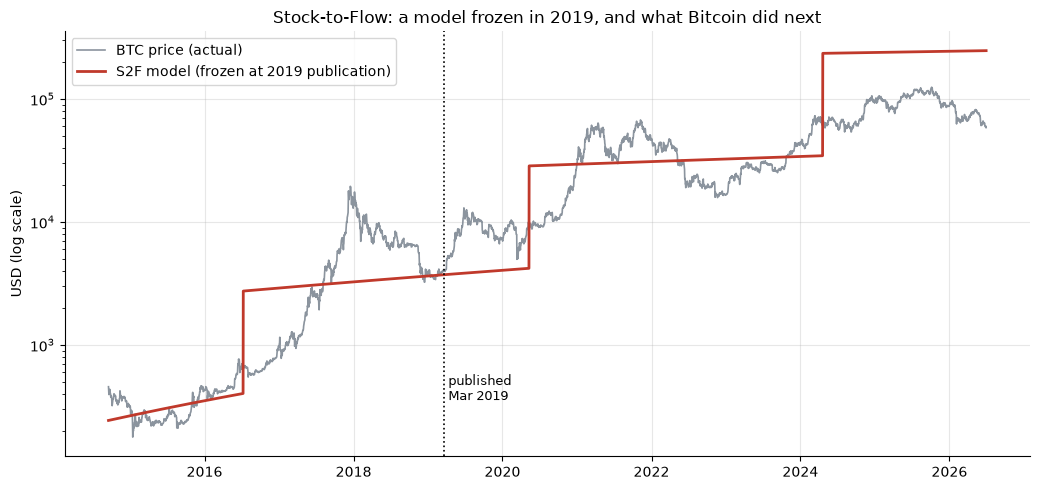

In [2]:
if HAVE_REAL:
    price = DF['price']; model = MODEL
    dfp = DF
else:
    price = model = dfp = None
fig, ax = plt.subplots(figsize=(10.5, 5.0))
if HAVE_REAL:
    ax.semilogy(price.index, price.values, color=GREY, lw=1.2, label='BTC price (actual)')
    ax.semilogy(model.index, model.values, color=RED, lw=2.0, label='S2F model (frozen at 2019 publication)')
    ax.axvline(pd.Timestamp(R['pub']), color='k', ls=':', lw=1.2)
    ax.text(pd.Timestamp(R['pub']), price.min()*2, ' published\n Mar 2019', fontsize=9)
else:
    ax.text(.5, .5, '(cached tape absent — see docs/results.md)', ha='center')
ax.set_ylabel('USD (log scale)')
ax.set_title('Stock-to-Flow: a model frozen in 2019, and what Bitcoin did next')
ax.legend(loc='upper left'); plt.tight_layout(); plt.show()

Left of the dotted line (before publication) the red model hugs the price — that's the **70%** in-sample fit. Right of it, watch the red line tear away: as stock-to-flow doubled at the 2024 halving, the model's predicted price exploded past **$247,369** while Bitcoin sat near **$58,559**. **Now — why was the fit so good, and why did it mean nothing?**

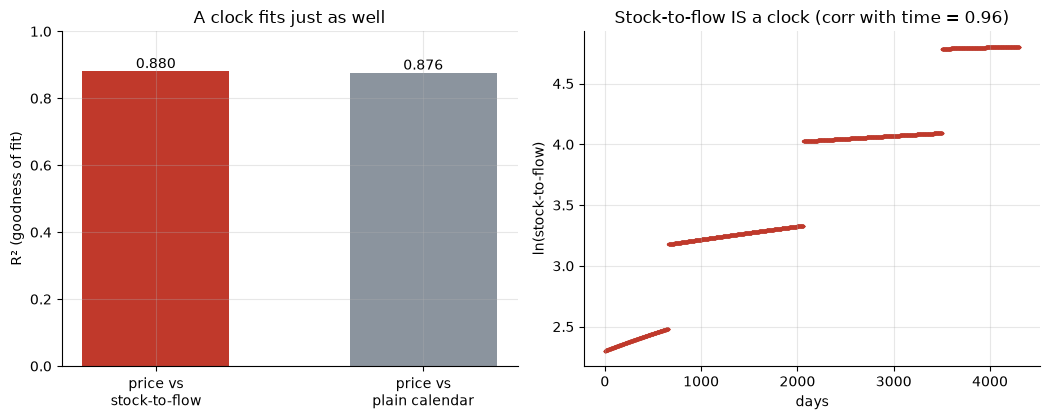

R2 price~S2F = 0.880   R2 price~time = 0.876   corr(lnSF,time) = 0.964


In [3]:
# Race the S2F fit against fitting price to a plain CLOCK
if HAVE_REAL:
    race = st.spurious_trend_race(DF)
    r2_sf, r2_time, corr = race['r2_sf'], race['r2_time'], race['corr_sf_time']
else:
    r2_sf, r2_time, corr = R['r2_sf'], R['r2_time'], R['corr_sf_time']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(['price vs\nstock-to-flow', 'price vs\nplain calendar'], [r2_sf, r2_time],
       color=[RED, GREY], width=.55)
for i, v in enumerate([r2_sf, r2_time]): a1.annotate(f'{v:.3f}', (i, v), ha='center', va='bottom')
a1.set_ylim(0, 1); a1.set_ylabel('R² (goodness of fit)')
a1.set_title('A clock fits just as well')
if HAVE_REAL:
    a2.scatter(np.arange(len(DF)), np.log(DF['sf'].values), s=2, color=RED)
    a2.set_xlabel('days'); a2.set_ylabel('ln(stock-to-flow)')
    a2.set_title(f'Stock-to-flow IS a clock (corr with time = {corr:.2f})')
else:
    a2.text(.5, .5, f'corr(ln SF, time) = {corr:.2f}', ha='center')
plt.tight_layout(); plt.show()
print(f'R2 price~S2F = {r2_sf:.3f}   R2 price~time = {r2_time:.3f}   corr(lnSF,time) = {corr:.3f}')

There's the whole trick. Stock-to-flow is a staircase set by a fixed schedule — it's **96%** the same thing as a calendar. So "fitting price to stock-to-flow" (R² 0.88) is almost identical to "fitting price to the passage of time" (R² 0.88). Any asset that trended up over these years would produce the same beautiful chart. The scarcity story adds essentially nothing the clock didn't already give you. **So did buying below the line at least pay?**

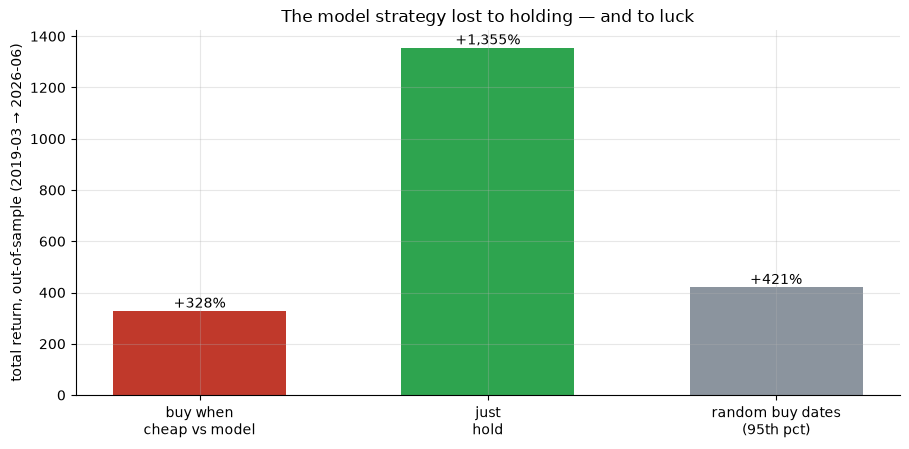

timer +328% (Sharpe 0.71) vs hold +1355% (Sharpe 0.91); random p95 +421%


In [4]:
if HAVE_REAL:
    tb = st.timer_backtest(DF, RESID, threshold=0.0, cost_bps=10.0, window_start=data.PUBLICATION_DATE)
    st_net, bh = tb['net_total_pct'], tb['bh_total_pct']
    st_shp, bh_shp = tb['net_sharpe'], tb['bh_sharpe']
    pl = st.random_placebo(DF, tb['exposure_pct'], cost_bps=10.0, window_start=data.PUBLICATION_DATE, n_draws=2000)
    plac = pl['p95_total_pct']
else:
    st_net, bh = R['oos_net'], R['oos_bh']
    st_shp, bh_shp = R['oos_net_sharpe'], R['oos_bh_sharpe']
    plac = R['oos_plac_p95']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
bars = ax.bar(['buy when\ncheap vs model', 'just\nhold', 'random buy dates\n(95th pct)'],
              [st_net, bh, plac], color=[RED, GREEN, GREY], width=.6)
for i, v in enumerate([st_net, bh, plac]): ax.annotate(f'{v:+,.0f}%', (i, v), ha='center', va='bottom')
ax.set_ylabel('total return, out-of-sample (2019-03 → 2026-06)')
ax.set_title('The model strategy lost to holding — and to luck')
plt.tight_layout(); plt.show()
print(f'timer {st_net:+.0f}% (Sharpe {st_shp:.2f}) vs hold {bh:+.0f}% (Sharpe {bh_shp:.2f}); random p95 {plac:+.0f}%')

Not close. Buying Bitcoin whenever it was "cheap vs the model" made **+328%** — versus **+1,355%** for just holding, and it was even *worse* on a risk-adjusted basis (Sharpe 0.71 vs 0.91). Worse still, that +328% doesn't even beat picking buy dates at **random** at the same frequency (whose luckiest 5% reach **+409%**). The model's valuation gap carried no usable information.

## 5 · The verdict

- **Signal — None.** The famous 95% fit is a *spurious regression*: stock-to-flow is 96% a clock, and a plain time-trend fits equally well. The valuation gap predicts nothing out-of-sample.
- **Tradability — Mirage.** Buying "cheap vs model" lost to buy-and-hold on both return and Sharpe, and didn't beat random buy dates.
- **Holds out-of-sample? — Busted.** Frozen at publication, the model's fit collapsed and it over-predicted price four-fold by 2026, right through a crash it said couldn't happen.

## 6 · Going further 🚪

- **The lesson outlives the model.** "High R²" on two trending series is the single most common way to fool yourself in markets. The fix is boring and non-negotiable: freeze the model at publication and score the future it never saw.
- **What would change our mind:** a version of S2F whose *out-of-sample* residual predicted returns with |t| ≥ 2 — we looked, at four horizons, and found nothing close.
- **Sibling studies:** [323-btc-halving](../../323-btc-halving/) (the halving as a *calendar event*, not a valuation), [293-mvrv-ratio](../../293-mvrv-ratio/) (a market-derived on-chain valuation ratio), [663-hash-ribbons](../../663-hash-ribbons/) (a miner-capitulation buy signal).

*Think a different fitting window, a market-cap model, or the 365-day-smoothed S2F rescues it? Fork the repo — the reconstruction is exact and the out-of-sample test is the only thing that counts.*